# Cell-cell communication of cytokine signalling

The tutorial `quick_start_cytokine_enrichment` shows you how the enrichment analysis is run in more detail. This tutorial shows how to compute and visualize cytokine-mediated cell-cell communication using huCIRA.


In [1]:
# Import core packages and the hucira package.

import os
import time
import warnings

import numpy as np
from tqdm import TqdmWarning

import hucira as hc

warnings.simplefilter("ignore", TqdmWarning)

start = time.time()

/lustre/groups/ml01/workspace/jenni.liu/conda_extern/envs/hucira/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
current_wd = os.getcwd()
print(current_wd)

/ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks


### Quick start cytokine signaling

Given a list of cytokines, `get_all_senders_and_receivers` identifies which cell types act as **senders** (produce the cytokine) and which act as **receivers** (express the corresponding receptor). This helps to map potential cytokine-mediated communication between immune cell types in your dataset.

Note: these signals reflect expression potential only and are not filtered for significance or robustness in this quick start tutorial.
If you know which cytokines you're interested in, you can define them and run cell-cell communication analysis directly. If you want to explore enriched signals in your query data, run the full enrichment analysis first and enter the output of all enriched signals after filtering of robust signals as a parameter to `plot_communication`(tutorial in second part). 

For a quick start, follow these steps:
1. Load cytokine information file from huCIRA.  
2. Define the cytokine(s) for which you want to compute signaling. They must be present in the cytokine information file to define sender and receiver relationships. The function will then identify which genes are in your query data as well.
3. Load your query adata. It needs to have feature names saved under `adata.var.index` in HGNC format to match nomenclature of cytokine info file.
4. Adjust threshold as needed. More about that in the advanced tutorial.

The files are saved to or loaded from the current working directory *current_wd*. The path is explicitly specified here, although it's also the default saving location if left unspecified.

In [3]:
# Load cytokine info file

cytokine_info = hc.load_cytokine_info(save_dir=current_wd)
cytokine_info.head()

Loading from: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks/cytokine_info.xlsx


,Unnamed: 0,name,gene,used cytokines,DEG_plot_family,single_family,family_level_1,family_level_2,receptor gene,alternative names,comments,parse_cytokine,single_gene,go_annotations,go_labels,functional_classification
0,0,IL-1-alpha,IL1A,IL-1α,IL-1,IL-1,interleukin,IL-1,"IL1R1, IL1RAP",Interleukin 1 alpha,NaN,True,IL1A,"['GO:0005125', 'GO:0046688', 'GO:0034605', 'GO...","cytokine activity, extracellular space, positi...",Pro-inflammatory
1,1,IL-1-beta,IL1B,IL-1β,IL-1,IL-1,interleukin,IL-1,"IL1R1, IL1RAP",Interleukin 1 beta,NaN,True,IL1B,"['GO:0005125', 'GO:0070372', 'GO:0001934', 'GO...","cytokine activity, positive regulation of prot...",Pro-inflammatory
2,2,IL-1Ra,IL1RN,IL-1Ra,IL-1,IL-1,interleukin,IL-1,IL1R1,Interleukin 1 receptor antagonist,NaN,True,IL1RN,"['GO:0006953', 'GO:0005813', 'GO:0005149', 'GO...","extracellular space, protein binding, cytosol,...",Anti-inflammatory
3,3,IL-18,IL18,IL-18,IL-1,IL-1,interleukin,IL-1,"IL18R1, IL18RAP",Interleukin 18,NaN,True,IL18,"['GO:0005125', 'GO:0005615', 'GO:0032819', 'GO...","cytokine activity, extracellular space, positi...","Pro-inflammatory, Th1-associated"
4,4,IL-33,IL33,IL-33,IL-1,IL-1,interleukin,IL-1,"IL1RL1, IL1RAP",Interleukin 33,NaN,True,IL33,"['GO:0005125', 'GO:0005737', 'GO:0005615', 'GO...","cytokine activity, cytoplasm, extracellular sp...",Pro-inflammatory


In [4]:
print("All cytokines present in the file:")
print(cytokine_info.name.unique())

All cytokines present in the file:
['IL-1-alpha' 'IL-1-beta' 'IL-1Ra' 'IL-18' 'IL-33' 'IL-36-alpha'
 'IL-36-beta' 'IL-36-gamma' 'IL-36Ra' 'IL-37' 'IL-38' 'IL-2' 'IL-7' 'IL-9'
 'IL-15' 'IL-21' 'IL-4' 'IL-13' 'IL-3' 'IL-5' 'GM-CSF' 'IL-6' 'IL-11'
 'IL-27' 'IL-30' 'IL-31' 'LIF' 'OSM' 'CT-1' 'IL-12' 'IL-23' 'IL-35'
 'IL-10' 'IL-19' 'IL-20' 'IL-22' 'IL-24' 'IL-26' 'IL-17A' 'IL-17B'
 'IL-17C' 'IL-17D' 'IL-17E' 'IL-17F' 'IL-16' 'IL-32-beta' 'TSLP'
 'IFN-alpha1' 'IFN-alpha2' 'IFN-alpha4' 'IFN-alpha5' 'IFN-alpha6'
 'IFN-alpha7' 'IFN-alpha8' 'IFN-alpha10' 'IFN-alpha13' 'IFN-alpha14'
 'IFN-alpha16' 'IFN-alpha17' 'IFN-alpha21' 'IFN-beta' 'IFN-epsilon'
 'IFN-kappa' 'IFN-omega' 'IFN-gamma' 'IFN-lambda1' 'IFN-lambda2'
 'IFN-lambda3' 'IFN-lambda4' 'TNF-alpha' 'LT-alpha1-beta2'
 'LT-alpha2-beta1' 'FasL' 'TRAIL' 'CD27L' 'CD30L' 'CD40L' 'OX40L' '4-1BBL'
 'GITRL' 'APRIL' 'BAFF' 'LIGHT' 'TL1A' 'RANKL' 'TWEAK' 'EDA' 'C1q' 'C3a'
 'C4a' 'C4b' 'C5a' 'Properdin' 'M-CSF' 'G-CSF' 'TGF-beta1' 'TGF-beta2'
 'TGF-bet

In [5]:
# Load your query data

adata = hc.load_multiple_sclerosis_data(save_dir=current_wd)
adata

Loading from: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks/MS_CSF.h5ad


AnnData object with n_obs × n_vars = 65326 × 10266
    obs: 'labels', 'MS', 'CSF', 'valid_clusters', 'CD4_labels'
    obsm: 'X_umap'

In [6]:
# Compute senders and receivers for (a) chosen cytokine(s) in your query data

df_senders, df_receivers = hc.get_all_senders_and_receivers(
    adata=adata,
    cytokine_info=cytokine_info,
    cytokine_list=["IL-15", "IL-7"],
    celltype_colname="labels",
    sender_pvalue_threshold=0.1,
    receiver_mean_X_threshold=0.1,
)

In [7]:
df_senders

,min_logfoldchanges,min_pvals,min_pvals_adj,gene,mean_X,frac_X,mean_X>0,cytokine,celltype
Gran,1.655668,0.0,0.0,IL15,0.083014,0.062886,0.083014,IL-15,Gran
Mono,2.027854,0.000022,0.000022,IL15,0.122385,0.113548,0.122385,IL-15,Mono
Mono Doublet,1.321865,0.000265,0.000265,IL15,0.077380,0.086847,0.077380,IL-15,Mono Doublet
ncMono,2.071975,0.0,0.0,IL15,0.122466,0.115276,0.122466,IL-15,ncMono
B1,2.646197,0.087981,0.087981,IL7,0.038835,0.024137,0.038835,IL-7,B1
B2,3.863949,0.000447,0.000447,IL7,0.086458,0.063812,0.086458,IL-7,B2


In [8]:
df_receivers

,mean_X,frac_X,cytokine,celltype
labels,,,,
B cell doublets,0.140399,0.120690,IL-15,B cell doublets
CD8a,0.207754,0.127662,IL-15,CD8a
Mono Doublet,0.117080,0.118044,IL-15,Mono Doublet
NK1,0.909494,0.465402,IL-15,NK1
NK2,0.914678,0.533137,IL-15,NK2
Tdg,0.198221,0.127036,IL-15,Tdg
Tregs,0.117986,0.084524,IL-15,Tregs
contamination1,0.101549,0.047091,IL-15,contamination1
B cell doublets,0.923470,0.596552,IL-7,B cell doublets


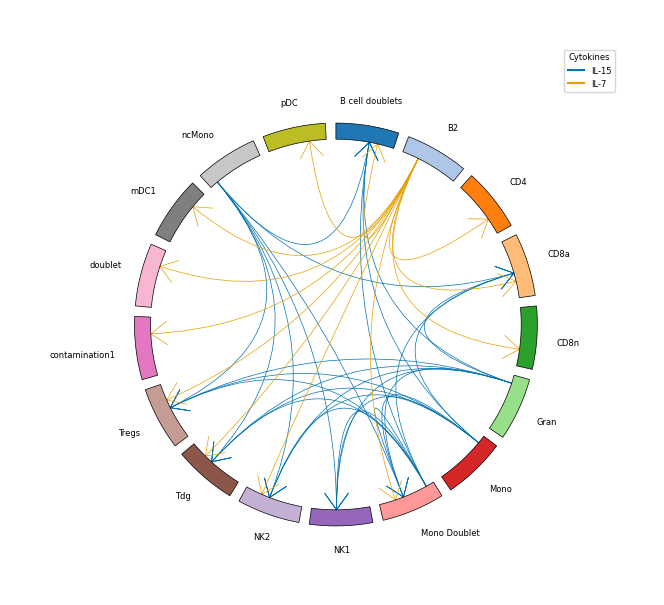

In [9]:
# Plots cell-cell communication

expression_threshold = 0.05

legend_handles, legend_labels = hc.plot_communication(
    df_src=df_senders,
    df_tgt=df_receivers,
    mean_cytokine_gene_expression_sender=expression_threshold,
    mean_cytokine_gene_expression_receiver=expression_threshold,
    show_legend=True,
    figsize=(6, 7),
    lw=0.5,
    fontsize=6,
    bbox_to_anchor=(1.1, 1.1),
    loc="center",
)

### Run a full enrichment analysis to visualize enriched and significant cytokine signals

To explore biologically relevant signals in your dataset in a more unbiased way, it is helpful to first run the enrichment analysis.  
`run_all_enrichment_test()` is a wrapper around the core function `run_one_enrichment_test()` and performs enrichment analyses across multiple cell types and across different filtering parameters used during gene set construction. In contrast, `run_one_enrichment_test()` focuses on a single specified cell type and does not allow assessment of robustness with respect to gene set construction parameters. More details are provided in the advanced tutorial.

In short, the wrapper returns results in a format that allows for more comprehensive downstream visualization, such as cell–cell communication plots.

For this cell–cell communication tutorial, we will compute enriched signals across a few selected cell types and then filter the results to keep only robust and statistically significant signals for visualization. To see how enrichment analyses are ran, refer to the quick start tutorial and/or the advanced tutorial.

In [10]:
# Load the human cytokine dictionary (mini version).

df_hcd_all = hc.load_human_cytokine_dict(save_dir=current_wd, mini_version=True)

Loading from: /ictstr01/home/icb/jenni.liu/all_projects/cytokine_dict_project/huCIRA/docs/notebooks/human_cytokine_dict_mini.csv


In [11]:
# Enter celltype column name and condition column name of your query adata
your_celltype_colname = "labels"
your_contrast_colname = "MS"

# Define celltype_combos, an input parameter for enrichment testing
adata_celltypes = ["B1", "CD8a", "Mono"]
hcd_celltypes = ["B_cell", "CD8_T_cell", "CD14_Mono"]

celltype_combos = hc.create_celltype_combos(adata_celltypes, hcd_celltypes)
print(celltype_combos)

# Define conditions of interest
contrast = ("True", "False")
print(contrast)

[('B1', 'B_cell'), ('CD8a', 'CD8_T_cell'), ('Mono', 'CD14_Mono')]
('True', 'False')


In [12]:
# Run robust enrichment analysis on a several celltypes and gene set parameters:

all_enrichment_results = hc.run_all_enrichment_test(
    adata=adata,
    df=df_hcd_all,
    contrast_combo=contrast,
    celltype_combos=celltype_combos,
    contrast_column=your_contrast_colname,
    celltype_column=your_celltype_colname,
    direction="upregulated",
    threshold_lfc=[0.8],
    threshold_expression=[0.05],
    threshold_pval=0.01,
)

# Look at all enrichment results (reduced view to columns of interest, not all statistics)
all_enrichment_results[
    [
        "celltype_combo",
        "cytokine",
        "contrast",
        "direction",
        "ES",
        "NES",
        "NOM p-val",
        "FDR q-val",
        "FWER p-val",
        "frac_shared_genes_signature",
        "Lead_genes",
        "threshold_lfc",
        "threshold_expression",
    ]
].sort_values("NES", ascending=False)

Computing gene sets of Human Cytokine Dictionary for B_cell.
Running enrichment for contrast: True_vs_False
Computing gene sets of Human Cytokine Dictionary for CD8_T_cell.
Running enrichment for contrast: True_vs_False
2026-03-10 15:03:02,534 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
Computing gene sets of Human Cytokine Dictionary for CD14_Mono.
Running enrichment for contrast: True_vs_False
2026-03-10 15:03:03,224 [WARNING] Duplicated values found in preranked stats: 0.02% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,celltype_combo,cytokine,contrast,direction,ES,NES,NOM p-val,FDR q-val,FWER p-val,frac_shared_genes_signature,Lead_genes,threshold_lfc,threshold_expression
0,CD8a (CD8_T_cell),IL-2,True_vs_False,upregulated,0.612847,2.079503,0.0,0.0,0.0,0.509091,ACTB;HSPA8;PRF1;IL32;UBB;PFN1;ACTG1;MYL12A;GZM...,0.8,0.05
1,CD8a (CD8_T_cell),IL-15,True_vs_False,upregulated,0.57136,2.022814,0.0,0.0,0.0,0.498920,ACTB;HSPA8;PRF1;IL32;PFN1;ACTG1;MYL12A;HNRNPF;...,0.8,0.05
2,CD8a (CD8_T_cell),IL-7,True_vs_False,upregulated,0.539797,1.830362,0.0,0.0,0.0,0.407186,ACTB;HSPA8;PRF1;IL32;MYL12A;TAP1;ENO1;GZMB;PSM...,0.8,0.05
0,B1 (B_cell),IL-21,True_vs_False,upregulated,0.604502,1.560405,0.019305,0.117342,0.1,0.246154,ACTB;CD180;ACTG1;ITGB2;PNP;MYO1G;CD19,0.8,0.05
0,Mono (CD14_Mono),M-CSF,True_vs_False,upregulated,0.443602,1.542205,0.0,0.126455,0.12,0.286533,AP1S2;DUSP6;BCL2A1;KCNN4;GIMAP6;HSP90AB1;ADAP2...,0.8,0.05
1,B1 (B_cell),CD40L,True_vs_False,upregulated,0.604784,1.518806,0.021684,0.09108,0.146,0.200000,TLR10;MARCKSL1;ANXA6;VIM,0.8,0.05
3,CD8a (CD8_T_cell),IL-1-beta,True_vs_False,upregulated,0.507223,1.509405,0.011173,0.031313,0.089,0.517241,TAP1;MT-CO1;PSME2;GAPDH;STOM;IFITM2;ISG15;GBP1...,0.8,0.05
4,CD8a (CD8_T_cell),IFN-omega,True_vs_False,upregulated,0.452022,1.507522,0.002064,0.02549,0.09,0.406015,HSPA8;PRF1;TAP1;PSME2;IFI16;IFITM2;ALOX5AP;PGA...,0.8,0.05
5,CD8a (CD8_T_cell),IL-1-alpha,True_vs_False,upregulated,0.614064,1.498569,0.029446,0.023439,0.1,0.375000,ISG15;GBP1;APOL2;EPSTI1;MX1;GBP5;PARP9;RTP4;FB...,0.8,0.05
2,B1 (B_cell),IL-7,True_vs_False,upregulated,0.637046,1.444307,0.054161,0.129635,0.276,0.133333,HSPA8;TNFSF10;MX1,0.8,0.05


In [13]:
robust_results = hc.check_robustness(
    all_results=all_enrichment_results,
    threshold_qval=0.15,  # chosen leniently to visualize more cytokines
    threshold_valid=0.0,
    threshold_below_alpha=0.0,
)
robust_results

100%|██████████| 3/3 [00:00<00:00, 26.67it/s]


,celltype_combo,contrast,cytokine,frac_valid,frac_significant,is_robust,NES_min,NES_max,FDR q-val,qval_threshold,threshold_frac_below_alpha
0,B1 (B_cell),True_vs_False,IL-21,1.0,1.0,True,1.560405,1.560405,0.117342,0.15,0.0
1,B1 (B_cell),True_vs_False,CD40L,1.0,1.0,True,1.518806,1.518806,0.091080,0.15,0.0
2,B1 (B_cell),True_vs_False,IL-7,1.0,1.0,True,1.444307,1.444307,0.129635,0.15,0.0
3,CD8a (CD8_T_cell),True_vs_False,IL-2,1.0,1.0,True,2.079503,2.079503,0.000000,0.15,0.0
4,CD8a (CD8_T_cell),True_vs_False,IL-15,1.0,1.0,True,2.022814,2.022814,0.000000,0.15,0.0
5,CD8a (CD8_T_cell),True_vs_False,IL-7,1.0,1.0,True,1.830362,1.830362,0.000000,0.15,0.0
6,CD8a (CD8_T_cell),True_vs_False,IL-1-beta,1.0,1.0,True,1.509405,1.509405,0.031313,0.15,0.0
7,CD8a (CD8_T_cell),True_vs_False,IFN-omega,1.0,1.0,True,1.507522,1.507522,0.025490,0.15,0.0
8,CD8a (CD8_T_cell),True_vs_False,IL-1-alpha,1.0,1.0,True,1.498569,1.498569,0.023439,0.15,0.0
9,CD8a (CD8_T_cell),True_vs_False,IFN-beta,1.0,1.0,True,1.420999,1.420999,0.046616,0.15,0.0


In [14]:
cytokines_IL_family = [
    "IL-1-alpha",
    "IL-1-beta",
    "IL-10",
    "IL-11",
    "IL-12",
    "IL-13",
    "IL-15",
    "IL-16",
    "IL-17A",
    "IL-17B",
    "IL-17C",
    "IL-17D",
    "IL-17E",
    "IL-17F",
    "IL-18",
    "IL-19",
    "IL-1Ra",
    "IL-2",
    "IL-20",
    "IL-21",
    "IL-22",
    "IL-23",
    "IL-24",
    "IL-26",
    "IL-27",
    "IL-3",
    "IL-31",
    "IL-32-beta",
    "IL-33",
    "IL-34",
    "IL-35",
    "IL-36-alpha",
    "IL-36Ra",
    "IL-4",
    "IL-5",
    "IL-6",
    "IL-7",
    "IL-8",
    "IL-9",
]
print(f"Num of cytokines to be plotted: {len(cytokines_IL_family)}")

Num of cytokines to be plotted: 39


In [15]:
# Compute cytokine senders and receivers per cell type for cytokines
df_senders, df_receivers = hc.get_all_senders_and_receivers(
    adata=adata,
    cytokine_info=cytokine_info,
    cytokine_list=cytokines_IL_family,
    celltype_colname=your_celltype_colname,
    sender_pvalue_threshold=0.1,
    receiver_mean_X_threshold=0,
)

None of the cytokine producing genes (['IL1A']) were found in dataset for cytokine IL-1-alpha.
None of the cytokine receptor genes (['IL1R1' 'IL1RAP']) were found in dataset for cytokine IL-1-alpha.
None of the cytokine receptor genes (['IL1R1' 'IL1RAP']) were found in dataset for cytokine IL-1-beta.
None of the cytokine producing genes (['IL11']) were found in dataset for cytokine IL-11.
None of the cytokine producing genes (['IL12A' 'IL12B']) were found in dataset for cytokine IL-12.
The following cytokine receptor genes were not found in the dataset and are excluded: ['IL12RB2']
None of the cytokine producing genes (['IL13']) were found in dataset for cytokine IL-13.
None of the cytokine producing genes (['IL17A']) were found in dataset for cytokine IL-17A.
The following cytokine receptor genes were not found in the dataset and are excluded: ['IL17RC']
None of the cytokine producing genes (['IL17B']) were found in dataset for cytokine IL-17B.
The following cytokine receptor genes we

In [16]:
df_senders

,min_logfoldchanges,min_pvals,min_pvals_adj,gene,mean_X,frac_X,mean_X>0,cytokine,celltype
Mono Doublet,3.002076,0.000001,0.000001,IL10,0.101699,0.091906,0.101699,IL-10,Mono Doublet
ncMono,5.035968,0.0,0.0,IL10,0.267259,0.190240,0.267259,IL-10,ncMono
Gran,1.655668,0.0,0.0,IL15,0.083014,0.062886,0.083014,IL-15,Gran
Mono,2.027854,0.000022,0.000022,IL15,0.122385,0.113548,0.122385,IL-15,Mono
Mono Doublet,1.321865,0.000265,0.000265,IL15,0.077380,0.086847,0.077380,IL-15,Mono Doublet
ncMono,2.071975,0.0,0.0,IL15,0.122466,0.115276,0.122466,IL-15,ncMono
B cell doublets,0.849211,0.000001,0.000001,IL16,0.489709,0.406897,0.489709,IL-16,B cell doublets
B2,0.476345,0.000042,0.000042,IL16,0.396229,0.278757,0.396229,IL-16,B2
CD4,0.246106,0.0,0.0,IL16,0.329181,0.223700,0.329181,IL-16,CD4
CD8a,0.276222,0.00017,0.00017,IL16,0.345714,0.212637,0.345714,IL-16,CD8a


In [17]:
df_receivers

,mean_X,frac_X,cytokine,celltype
B1,0.099969,0.062755,IL-10,B1
B2,0.152840,0.115029,IL-10,B2
B cell doublets,0.133764,0.131034,IL-10,B cell doublets
CD4,0.114350,0.081498,IL-10,CD4
CD8a,0.121640,0.077910,IL-10,CD8a
...,...,...,...,...
mDC1,0.167398,0.151163,IL-7,mDC1
mDC2,0.072470,0.072091,IL-7,mDC2
ncMono,0.048336,0.043140,IL-7,ncMono
pDC,0.107447,0.080597,IL-7,pDC


expression_threshold is 1.4426878274712997e-05


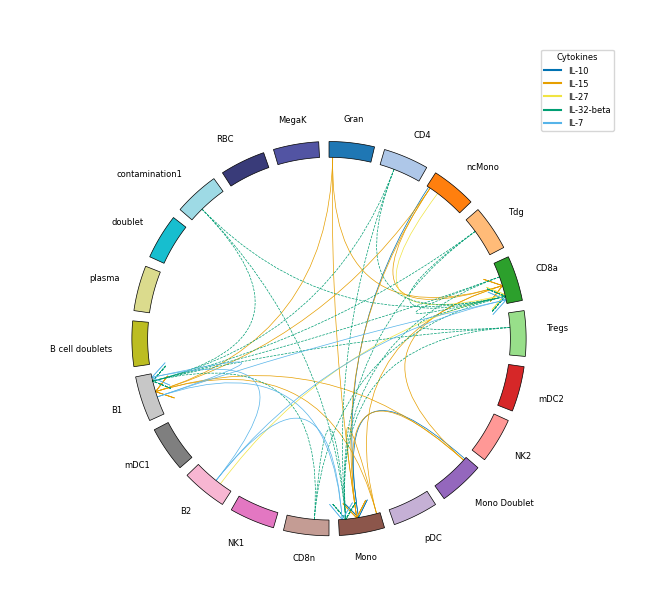

In [18]:
# Plots cell-cell communication: all enrichment results

# Define a minimum expression threshold of genes
expression_threshold = 0.1 / 10_000  # 100 transcripts per million
expression_threshold = np.log2((expression_threshold) + 1)
print(f"expression_threshold is {expression_threshold}")

# All celltypes in query data:
all_query_data_ct = np.array(adata.obs[your_celltype_colname].unique())

legend_handles, legend_labels = hc.plot_communication(
    df_src=df_senders,
    df_tgt=df_receivers,
    frac_expressing_cells_sender=0,
    frac_expressing_cells_receiver=0,
    mean_cytokine_gene_expression_sender=expression_threshold,
    mean_cytokine_gene_expression_receiver=expression_threshold,
    df_enrichment=all_enrichment_results,
    all_celltypes=all_query_data_ct,
    show_legend=True,
    figsize=(6, 7),
    lw=0.5,
    fontsize=6,
    bbox_to_anchor=(1.1, 1.1),
    loc="center",
)

expression_threshold is 1.4426878274712997e-05


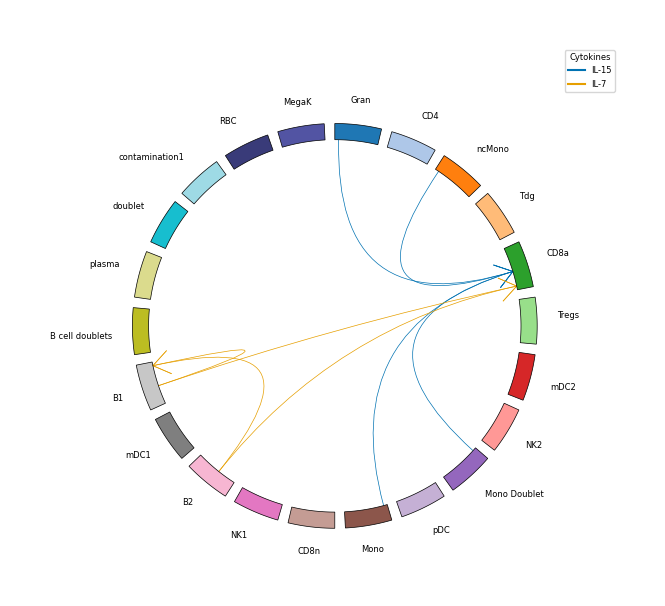

In [19]:
# Plots cell-cell communication: only robust and statistically significant results

# Define a minimum expression threshold of genes
expression_threshold = 0.1 / 10_000  # 100 transcripts per million
expression_threshold = np.log2((expression_threshold) + 1)
print(f"expression_threshold is {expression_threshold}")

# All celltypes in query data:
all_query_data_ct = np.array(adata.obs[your_celltype_colname].unique())


legend_handles, legend_labels = hc.plot_communication(
    df_src=df_senders,
    df_tgt=df_receivers,
    frac_expressing_cells_sender=0,
    frac_expressing_cells_receiver=0,
    mean_cytokine_gene_expression_sender=expression_threshold,
    mean_cytokine_gene_expression_receiver=expression_threshold,
    df_enrichment=robust_results,
    all_celltypes=all_query_data_ct,
    show_legend=True,
    figsize=(6, 7),
    lw=0.5,
    fontsize=6,
    bbox_to_anchor=(1.1, 1.1),
    loc="center",
)

In [20]:
end = time.time()
print(f"Time: {int((end - start) / 60)} min {int((end - start) % 60)} sec")

Time: 0 min 36 sec


In [10]:
## --END-- ##